# QB Decision Making Report

Tom Henehan - June 9, 2026

This notebook is for looking at the final results from the project. It uses the CSV files made by the scripts.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

out_dir = Path('expected_yards_output_all_weeks')
analysis_dir = out_dir / 'analysis'
fig_dir = analysis_dir / 'figures'

## QB Summary

In [2]:
qb = pd.read_csv(analysis_dir / 'qb_summary_all.csv')
cols = [
    'passer_name', 'throws', 'missed_xyards', 'best_choice_rate_p50',
    'acceptable_choice_rate_p50', 'timing_loss_xyards_p50',
    'acceptable_timing_rate_p50', 'result_yards_over_expected'
]
qb[[c for c in cols if c in qb.columns]].sort_values('missed_xyards').head(20)

,passer_name,throws,missed_xyards,best_choice_rate_p50,acceptable_choice_rate_p50,timing_loss_xyards_p50,acceptable_timing_rate_p50,result_yards_over_expected
61,Braxton Berrios,1,0.000000,1.000000,1.000000,1.614325,0.000000,-2.766611
60,Justin Jefferson,1,0.000000,1.000000,1.000000,0.000000,1.000000,5.700597
59,Tyrod Taylor,3,0.765611,0.666667,0.666667,4.180134,0.000000,-4.140493
58,Jordan Love,3,1.011337,0.666667,0.666667,3.103185,0.333333,0.153361
57,Tyler Boyd,1,1.107530,0.000000,0.000000,4.991037,0.000000,9.502620
56,Taysom Hill,2,1.261627,0.500000,0.500000,1.261627,0.500000,14.449270
55,Gardner Minshew,2,2.636011,0.000000,0.000000,4.100295,0.000000,3.629168
54,Lamar Jackson,177,2.906165,0.310734,0.446328,5.377709,0.118644,0.445617
53,Patrick Mahomes,219,3.164708,0.292237,0.392694,5.196854,0.114155,2.248190
52,Cooper Rush,113,3.290962,0.283186,0.407080,5.745145,0.061947,1.050508


## Model Error

,model,target,mae
0,sklearn_hist_gradient_boosting,air_yards,0.655144
1,sklearn_hist_gradient_boosting,yards_after_catch,3.717556
2,sklearn_hist_gradient_boosting,total_yards,3.853995
3,gat_temporal_transformer,air_yards,3.461171
4,gat_temporal_transformer,yards_after_catch,2.907342
5,gat_temporal_transformer,total_yards,5.793362


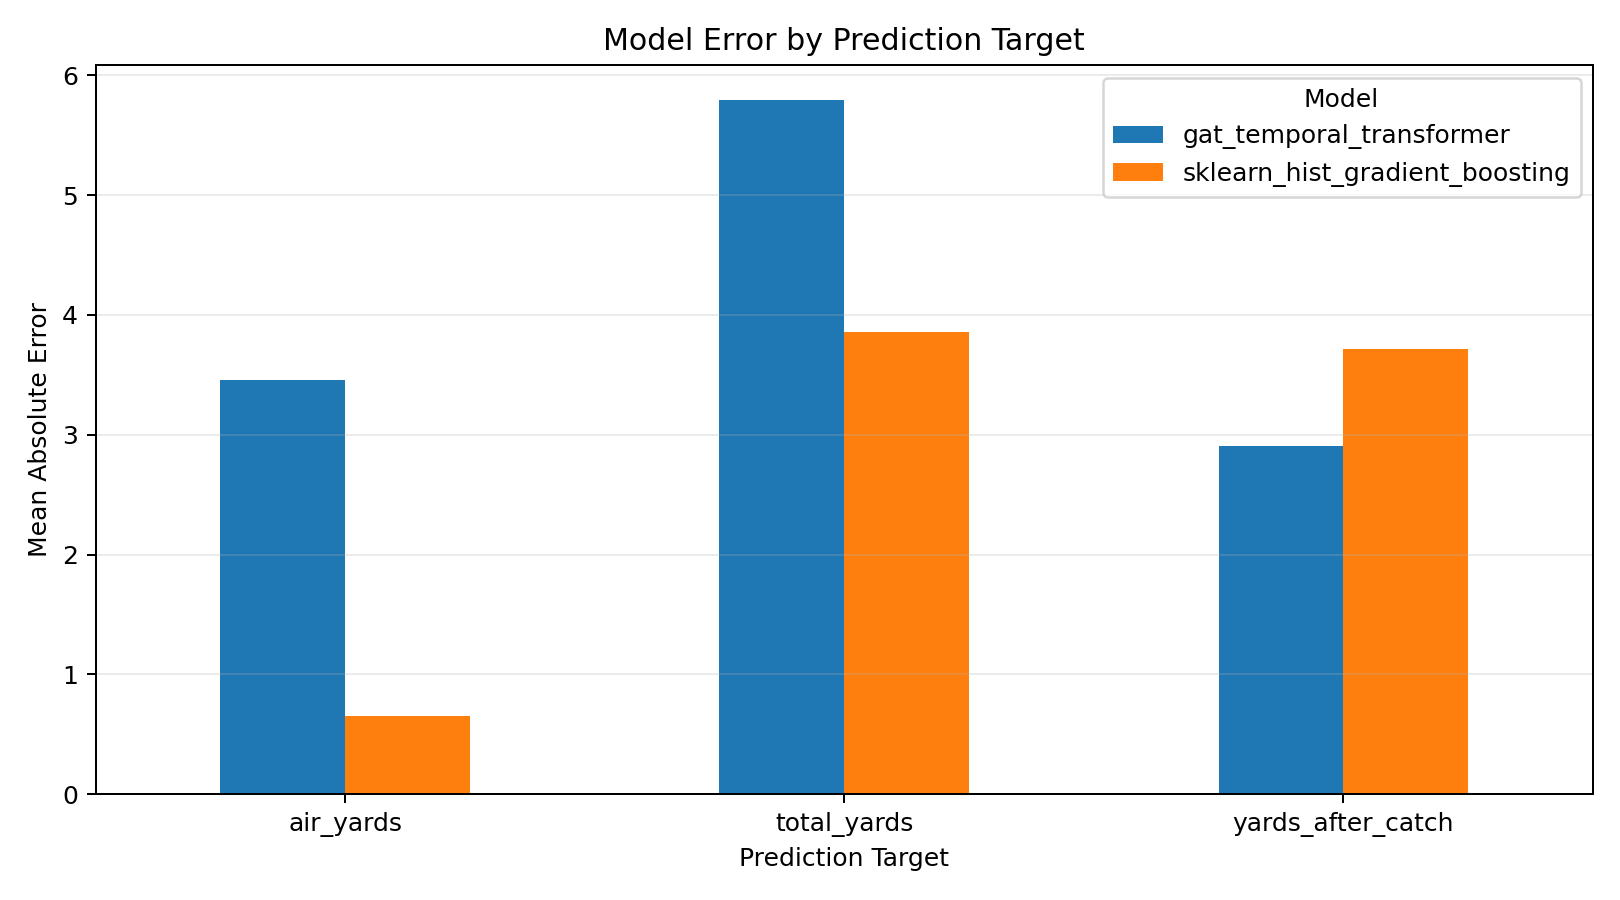

In [3]:
err_path = analysis_dir / 'model_error_comparison.csv'
if err_path.exists():
    display(pd.read_csv(err_path))
img_path = analysis_dir / 'model_error_comparison.png'
if img_path.exists():
    display(Image(filename=img_path))

## Visuals

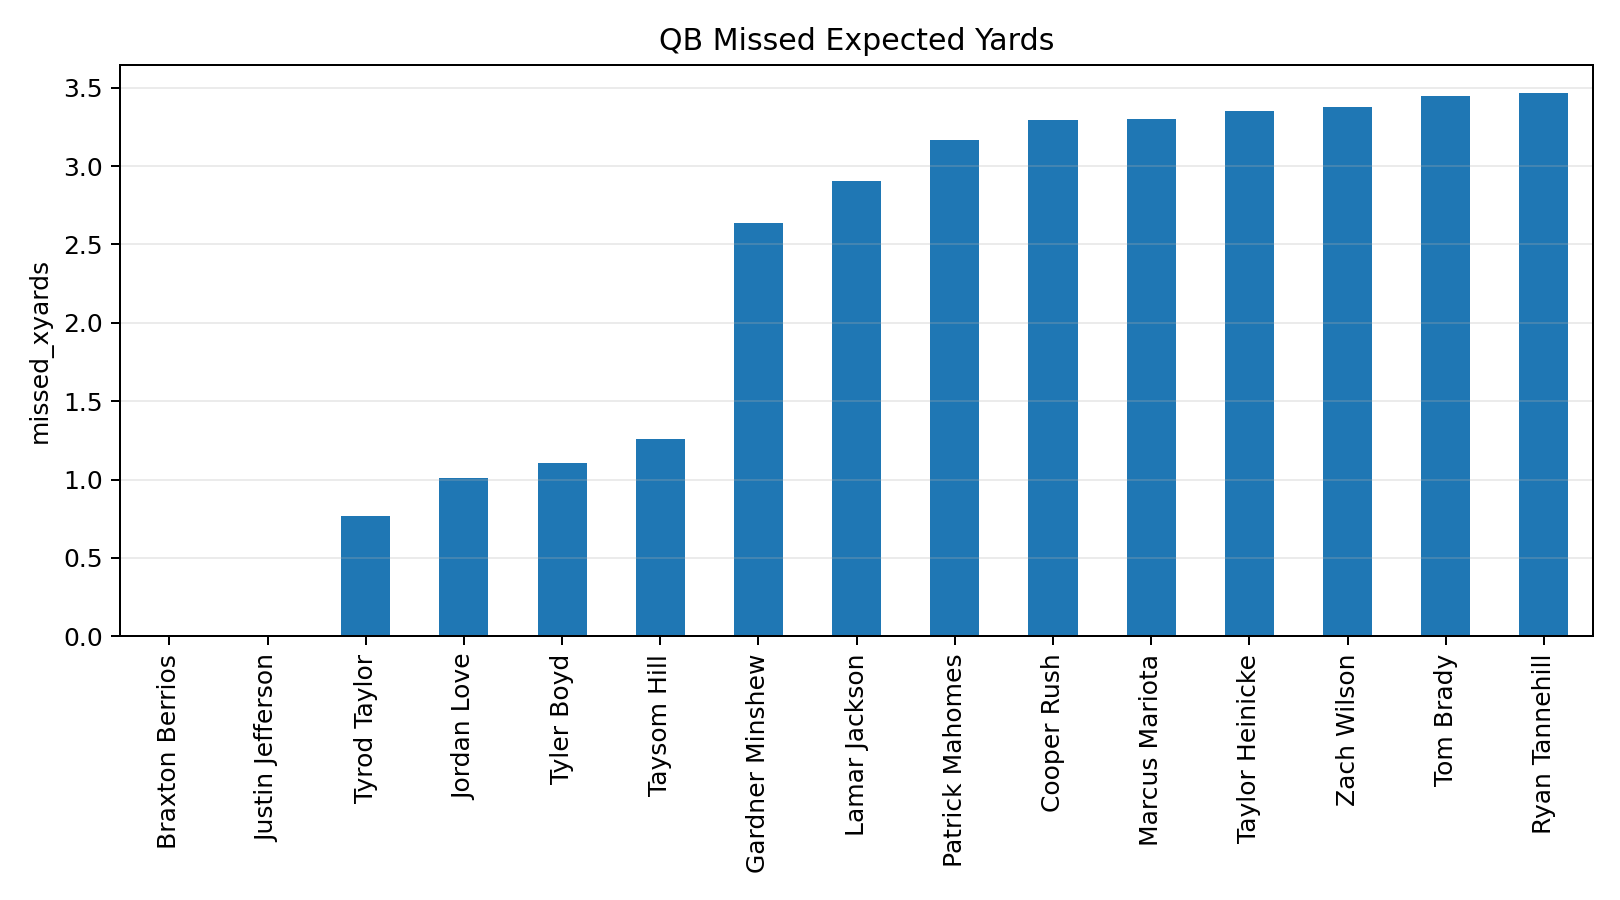

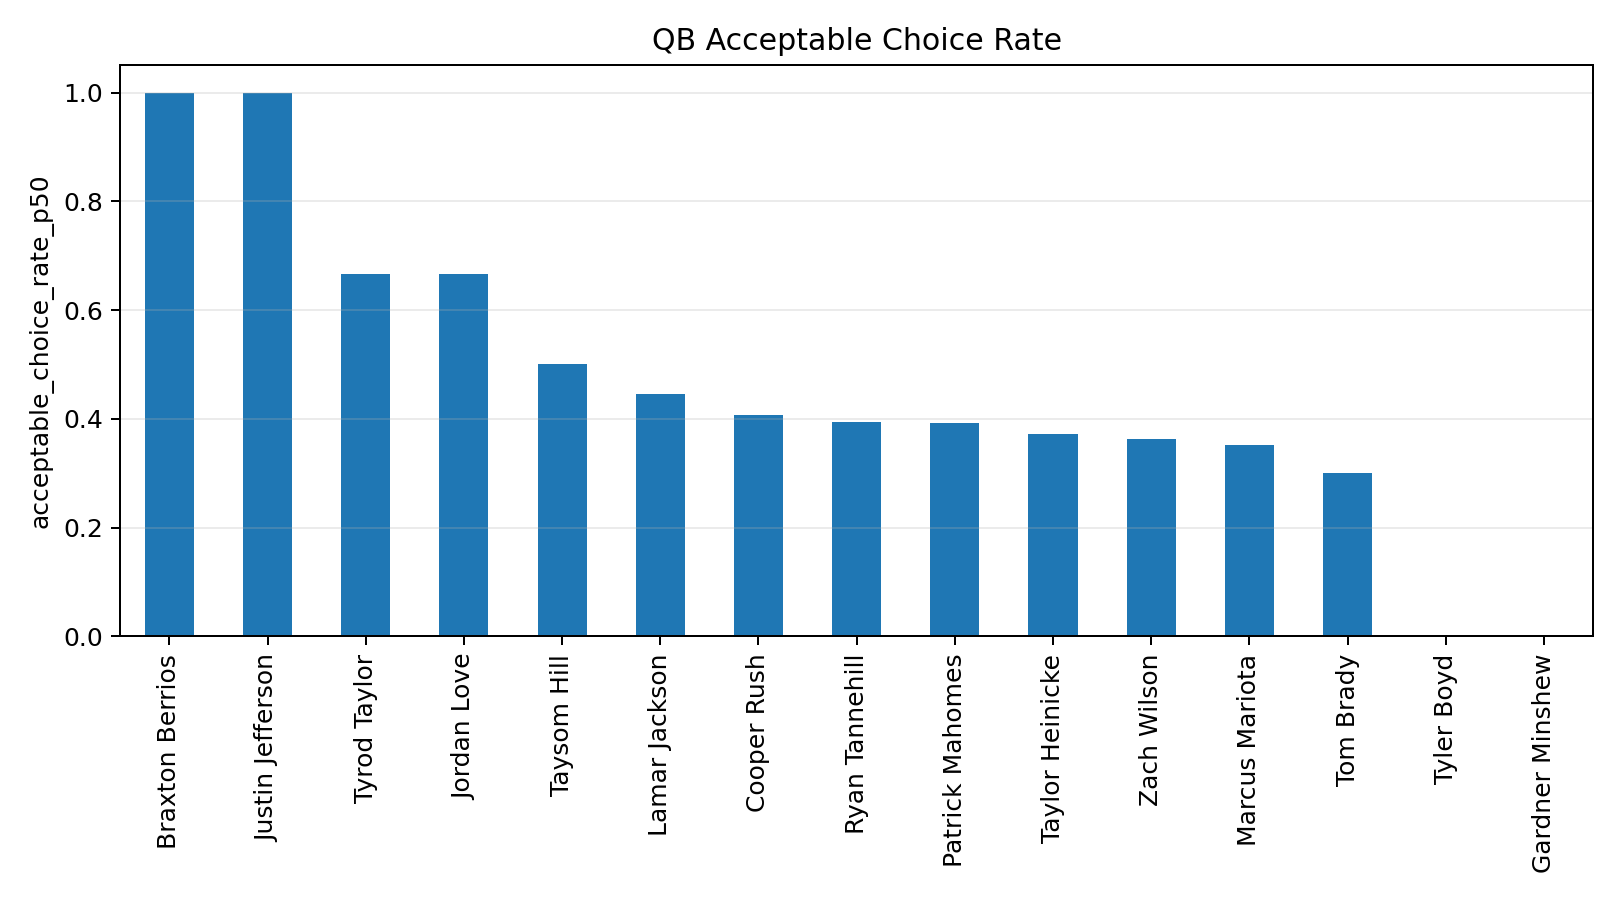

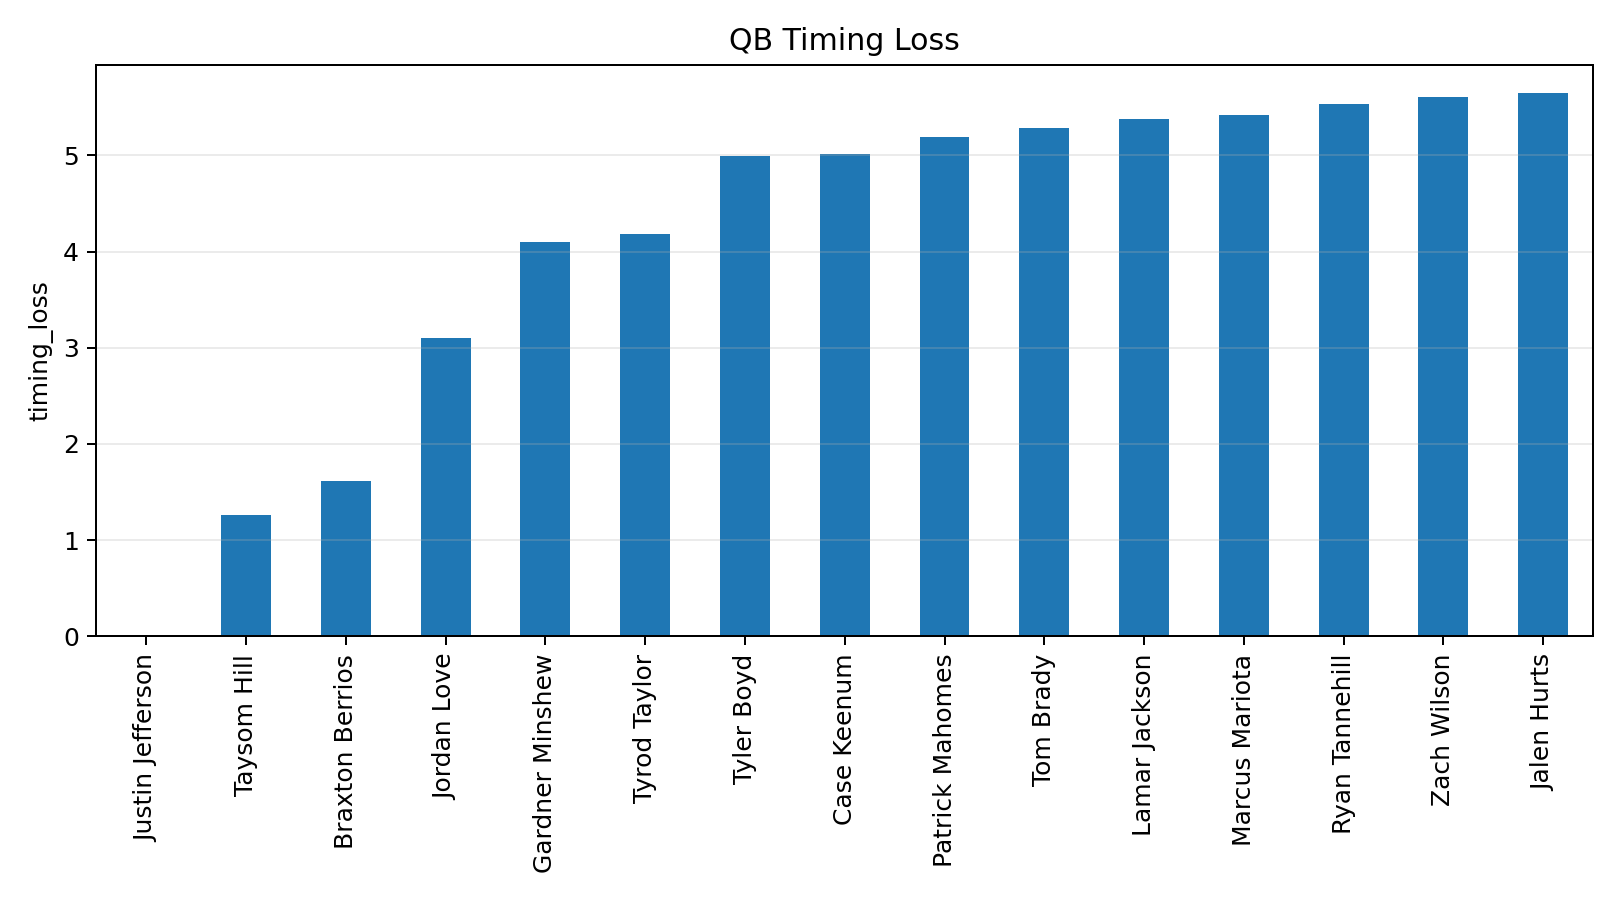

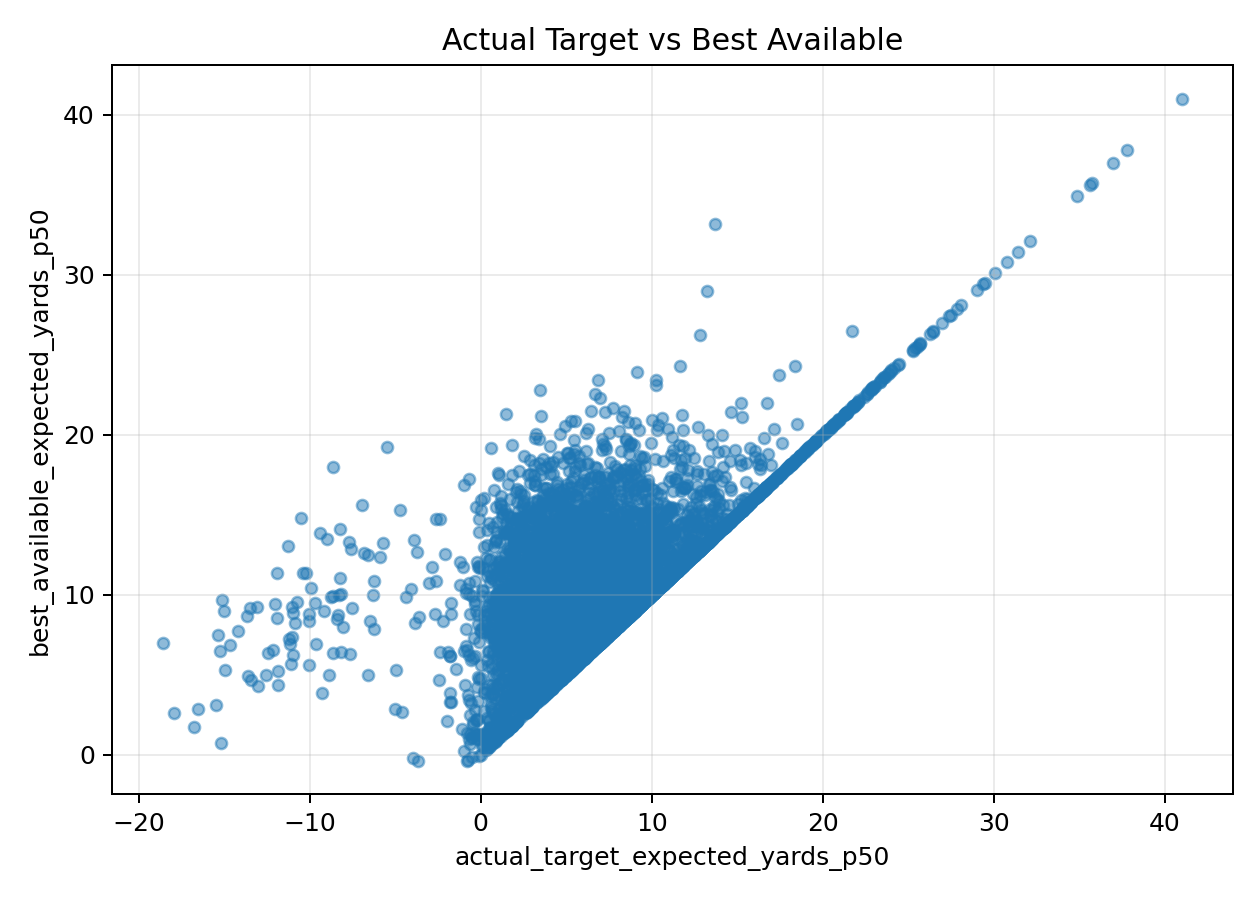

In [4]:
for name in ['qb_missed_yards.png', 'qb_acceptable_rate.png', 'qb_timing_loss.png', 'actual_vs_best_value.png']:
    path = fig_dir / name
    if path.exists():
        display(Image(filename=path))

## Top Missed Plays

In [5]:
top_path = analysis_dir / 'top_missed_plays_test.csv'
if top_path.exists():
    top = pd.read_csv(top_path)
    display(top.head(20))

,gameId,playId,split,passer_name,possessionTeam,defensiveTeam,down,yardsToGo,timeToThrow,actual_target_name,...,best_available_expected_yards_high,best_available_interception_yards_risk,missed_expected_yards,actual_target_predicted_epa,best_available_predicted_epa,missed_predicted_epa,actual_epa,passResult,pff_passCoverage,pff_manZone
0,2022103003,254,test,Tua Tagovailoa,MIA,DET,1,10,3.070,Alec Ingold,...,18.777681,-1.899910,15.823901,-0.105241,1.075453,1.180694,0.045006,C,Cover-3,Zone
1,2022103010,1012,test,Christian McCaffrey,SF,LA,2,8,3.737,Brandon Aiyuk,...,29.489923,-1.388343,15.741428,1.261899,2.162192,0.900293,3.526483,C,Cover-6 Right,Zone
2,2022103008,1480,test,Jalen Hurts,PHI,PIT,3,18,3.704,Kenneth Gainwell,...,19.553656,-2.520859,15.561315,-0.727129,1.612672,2.339801,-0.203188,C,Cover-3,Zone
3,2022103003,56,test,Jared Goff,DET,MIA,1,10,3.037,Jamaal Williams,...,23.502560,-2.015878,15.329831,0.035636,0.826311,0.790676,1.641564,C,Cover-3,Zone
4,2022103006,1525,test,Derek Carr,LV,NO,3,4,4.138,Foster Moreau,...,23.213879,-2.727381,15.037927,0.445087,3.357376,2.912289,1.181641,C,Cover-2,Zone
5,2022103008,1371,test,Kenny Pickett,PIT,PHI,3,19,2.169,Jaylen Warren,...,18.338775,-1.971521,14.387416,-0.603548,1.207670,1.811218,0.024703,C,Quarters,Zone
6,2022110608,2561,test,Geno Smith,SEA,ARI,2,9,2.403,Will Dissly,...,21.985212,-2.168159,14.249382,-0.162399,1.491283,1.653682,-0.129484,C,Cover-3,Zone
7,2022103008,3772,test,Kenny Pickett,PIT,PHI,1,10,3.003,Jaylen Warren,...,16.042315,-2.727381,14.164006,-0.576259,0.944843,1.521101,1.030598,C,Quarters,Zone
8,2022103001,3671,test,P.J. Walker,CAR,ATL,2,9,4.038,Spencer Brown,...,22.711511,-2.015878,14.154305,0.328831,1.087586,0.758755,-0.573507,I,Cover-2,Zone
9,2022110603,1117,test,Jared Goff,DET,GB,2,12,2.235,Amon-Ra St. Brown,...,20.466200,-1.092064,13.711660,-0.127506,1.602721,1.730227,-0.194791,C,Cover-3,Zone
